# 06 — Regression & GAM partial dependence (A6)
**Kernel: `Python (pf_ml)`.** Standardized linear/quantile regression for the **partial** shear effect (controlling CAPE, CIN, moisture, skin-temp, |lat|); quantile regression at τ=0.9/0.99 targets the intensity tail; a GAM gives the nonlinear isolated shear curve. Echo-top-height models use the deep subset (features that actually contain a 40-dBZ echo).

In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, warnings; warnings.filterwarnings('ignore')
from functools import reduce
from _shc import *
con = connect()
# Predictors: ambient CAPE + CIN + moisture + SKIN TEMP (skt; defined over land&ocean,
# unlike SST) + 3 shear layers + |lat|.  Treatment = 0-6 km shear.
PREDICTORS = [AMBIENT_CAPE, CIN, MOISTURE, 'mean_skt_2p50deg',
              'shear_1000m_centroid','shear_3000m_centroid','shear_6000m_centroid','abs_lat']
TREATMENT  = SHEAR
RESPONSES  = ['ht40_km','ht30_km','ht20_km','min_pct_85_89','min_pct_37']
# max_ht_40dbz is NULL when no 40-dBZ echo exists -> for echo-top HEIGHT models we sample the
# deep subset (finite ht40); CIN is occasionally NULL -> impute 0 (no inhibition).

import statsmodels.api as sm
df = load_sample(con, RESPONSES+PREDICTORS, mission='TRMM', n=200_000, where='AND ht40_km IS NOT NULL')
df[CIN] = df[CIN].fillna(0.0); df = df.dropna(subset=PREDICTORS+['ht40_km'])
print('deep-convective sample:', df.shape)
Z = sm.add_constant((df[PREDICTORS]-df[PREDICTORS].mean())/df[PREDICTORS].std())

deep-convective sample: (200000, 13)


### Standardized OLS + quantile regression of the 40-dBZ top (partial shear effect)

In [2]:
y = df['ht40_km']
ols = sm.OLS(y, Z).fit()
print('OLS standardized coefficients (|largest| first):')
print(ols.params.drop('const').sort_values(key=abs, ascending=False).round(3).to_string())
for tau in [0.5, 0.9, 0.99]:
    p = sm.QuantReg(y, Z).fit(q=tau).params
    print(f'  tau={tau}: shear6={p["shear_6000m_centroid"]:+.3f}  CAPE={p[AMBIENT_CAPE]:+.3f}  CIN={p[CIN]:+.3f}')

OLS standardized coefficients (|largest| first):
p90_cape_2p50deg        0.520
mean_tpr_2p50deg        0.392
mean_cin_2p50deg        0.261
shear_6000m_centroid   -0.215
shear_1000m_centroid   -0.196
shear_3000m_centroid    0.133
mean_skt_2p50deg       -0.097
abs_lat                 0.061


  tau=0.5: shear6=-0.185  CAPE=+0.551  CIN=+0.251


  tau=0.9: shear6=-0.380  CAPE=+0.678  CIN=+0.534


  tau=0.99: shear6=-0.355  CAPE=+1.108  CIN=+0.896


### GAM partial dependence of shear (nonlinear, others held)

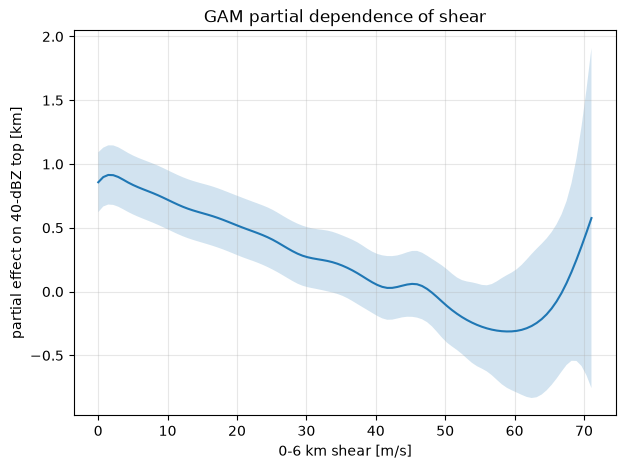

In [3]:
from pygam import LinearGAM, s
terms = reduce(lambda a, b: a + b, [s(i) for i in range(len(PREDICTORS))])
gam = LinearGAM(terms).fit(df[PREDICTORS].to_numpy(), df['ht40_km'].to_numpy())
j = PREDICTORS.index('shear_6000m_centroid')
XX = gam.generate_X_grid(term=j); pdep, ci = gam.partial_dependence(term=j, X=XX, width=0.95)
plt.figure(figsize=(7,5)); plt.plot(XX[:,j], pdep); plt.fill_between(XX[:,j], ci[:,0], ci[:,1], alpha=.2)
plt.xlabel('0-6 km shear [m/s]'); plt.ylabel('partial effect on 40-dBZ top [km]')
plt.title('GAM partial dependence of shear'); plt.grid(alpha=.3); plt.show()